In [1]:
import os
import numpy as np
import pandas as pd
import nibabel as nib
from nibabel.processing import resample_from_to
from neurosynth.base.dataset import Dataset
from neurosynth.analysis import decode
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl

E:\Application\Miniconda\envs\cognition_decoding\lib\site-packages\matplotlib\__init__.py:886: MatplotlibDeprecationWarning: 
examples.directory is deprecated; in the future, examples will be found relative to the 'datapath' directory.
  "found relative to the 'datapath' directory.".format(key))


In [2]:
mpl.rcParams['svg.fonttype'] = 'none'
TARGET_SHAPE = (91, 109, 91)
TARGET_AFFINE = np.array([[  -2.,    0.,    0.,   90.],
                          [   0.,    2.,    0., -126.],
                          [   0.,    0.,    2.,  -72.],
                          [   0.,    0.,    0.,    1.]])
TARGET_IMG = nib.Nifti1Image(np.zeros(TARGET_SHAPE), TARGET_AFFINE)

In [3]:
def ensure_mni_2mm(input_path):
    """检查并重采样图像到 MNI 2mm 空间"""
    img = nib.load(input_path)
    # 检查 shape 和 affine 是否匹配
    if img.shape != TARGET_SHAPE or not np.allclose(img.affine, TARGET_AFFINE):
        print(f"分辨率不符，正在重采样: {os.path.basename(input_path)}")
        resampled_img = resample_from_to(img, TARGET_IMG, order=0)
        return resampled_img
    return img

def generate_bins(input_img, output_dir, n_bins=20):
    """将连续数值地图按百分比划分为 Bin (从数值小到大排列)"""
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
    
    data = input_img.get_fdata()
    affine = input_img.affine
    
    # 获取所有非零/非 NaN 体素的索引和数值
    flat_data = data.flatten()
    valid_indices = np.where((flat_data != 0) & (~np.isnan(flat_data)))[0]
    valid_values = flat_data[valid_indices]
    
    sorted_idx_in_valid = np.argsort(valid_values)
    sorted_global_indices = valid_indices[sorted_idx_in_valid]
    
    # 划分为 n_bins 组
    bin_arrays = np.array_split(sorted_global_indices, n_bins)
    
    bin_paths = []
    for i, idx_group in enumerate(bin_arrays):
        bin_data = np.zeros_like(flat_data)
        bin_data[idx_group] = 1 
        
        bin_img = nib.Nifti1Image(bin_data.reshape(data.shape), affine)
        fname = f'bin_{i+1:02d}.nii'
        fpath = os.path.join(output_dir, fname)
        nib.save(bin_img, fpath)
        bin_paths.append(fpath)
        
    print(f"成功按升序生成 {n_bins} 个 Bin 文件于: {output_dir}")
    return bin_paths

def getOrder(d, thr):
    """计算热图排序"""
    dh = []
    for i in range(len(d)):
        di = d[i]
        if np.sum(di) == 0:
            dh.append(0)
        else:
            dh.append(np.average(np.array(range(len(di))) + 1, weights=di))
    return np.argsort(dh)

In [4]:
# # Create a new Dataset instance
dataset = Dataset('database_feb_2015/database.txt')
# Add some features
dataset.add_features('database_feb_2015/features.txt')
dataset.save('database_feb_2015/dataset.pkl')
#dataset
#OR
# Import neurosynth database:
# pickled_dataset='database_feb_2015/dataset.pkl' 
# dataset=Dataset.load(pickled_dataset)

In [5]:
# Analysis with 24 terms:
features = pd.read_csv('database_feb_2015/v3-topics-50.txt', sep='\t', index_col=0)
topics_to_keep = [ 1, 4,  6, 14, 
                  18, 19, 23, 25, 
                  20, 21, 27, 29,
                  30, 31, 33, 35, 
                  36, 38, 37, 41, 
                  44, 45, 48, 49]
labels = ['face/affective processing', ' verbal semantics', 'cued attention', 'working memory', 
          'autobiographical memory', 'reading', 'inhibition', 'motor', 
          'visual perception', 'numerical cognition', 'reward-based decision making', 'visual attention', 
          'multisensory processing', 'visuospatial','eye movements', 'action',
          'auditory processing', 'pain', 'language', 'declarative memory', 
          'visual semantics', 'emotion', 'cognitive control', 'social cognition']
features = features.iloc[:, topics_to_keep]
features.columns = labels
dataset.add_features(features, append=False)

# removed_as_noise = [0,5,9,12,17,40] # from 30 terms that were above threshold
# labels_noise = ['resting-state', 'dementia', 'development', 'misc', 'task timing', 'lateralization']

In [7]:
nbins = 20
input_map_path = 'Reslice_group_temporal.nii' # 修改为你的原始地图路径
bin_output_dir = 'Bins'
if not os.path.exists(bin_output_dir):
    os.makedirs(output_dir)

resampled_img = ensure_mni_2mm(input_map_path)
bin_files = generate_bins(resampled_img, bin_output_dir, n_bins=nbins)

成功按升序生成 20 个 Bin 文件于: Bins


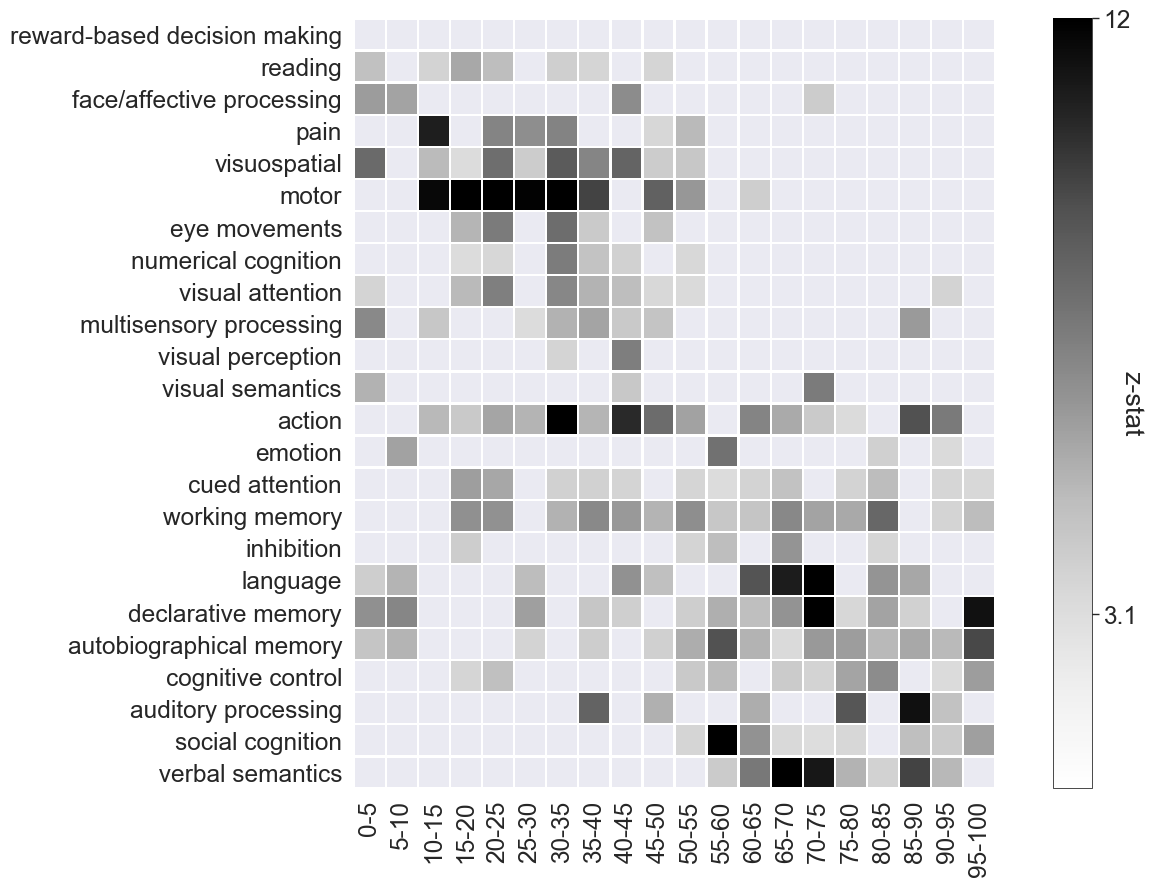

In [10]:
# Gradient 1

decoder = decode.Decoder(dataset, method='roi')

# Set threshold:
thr = 3.1
vmin = 5
vmax = 12

tot = int(100/nbins)
data = decoder.decode([str('bins/bin_%02d.nii' % (i)) 
                       for i in range(1,21)],save='decoding_results.txt')

df = []
df = data.copy()
newnames = []
[newnames.append(('%s-%s' % (str(i * tot), str((i*tot) + tot)))) for i in range(0,len(df.columns))]
df.columns = newnames
df[df<thr] = 0 
heatmapOrder = getOrder(np.array(df), thr)

sns.set(context="paper", font="sans-serif", font_scale=2)
f, (ax1) = plt.subplots(nrows=1,ncols=1,figsize=(15, 10), sharey=True)
plotData = df.reindex(df.index[heatmapOrder])
cax = sns.heatmap(plotData, linewidths=1, square=True, cmap='Greys', robust=False, 
            ax=ax1, vmin=0.5, vmax=vmax, mask=plotData == 0)
#sns.axlabel('Percentile along gradient', 'NeuroSynth topics terms')
cbar = cax.collections[0].colorbar
cbar.set_label('z-stat', rotation=270)
cbar.set_ticks(ticks=[thr,vmax])
cbar.set_ticklabels(ticklabels=[thr,vmax])
cbar.outline.set_edgecolor('black')
cbar.outline.set_linewidth(0.5)

plt.draw()
f.savefig('5_100.neurosynth.svg', format='svg')